# Analyse Exploratoire

### Import des modules

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

### Analyse Exploratoire

In [ ]:
path_2016 = "data/2016_Building_Energy_Benchmarking.csv"
path_hist = "data/Building_Energy_Benchmarking_Data,_2015-Present_20260316.csv"

df_2016 = pd.read_csv(path_2016, low_memory=False)
df_hist = pd.read_csv(path_hist, low_memory=False)

print("df_2016 :", df_2016.shape)
print("df_hist :", df_hist.shape)

Dimensions du jeu de données : (3376, 46)


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [ ]:
rename_2016 = {
    "PropertyName": "BuildingName",
    "PrimaryPropertyType": "EPAPropertyType",
    "PropertyGFABuilding(s)": "PropertyGFABuildings"
}

df_2016 = df_2016.rename(columns=rename_2016).copy()

In [ ]:
numeric_cols = [
    "OSEBuildingID",
    "DataYear",
    "CouncilDistrictCode",
    "Latitude",
    "Longitude",
    "YearBuilt",
    "NumberofBuildings",
    "NumberofFloors",
    "ENERGYSTARScore",
    "PropertyGFATotal",
    "PropertyGFAParking",
    "PropertyGFABuildings",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
    "Electricity(kWh)",
    "Electricity(kBtu)",
    "NaturalGas(therms)",
    "NaturalGas(kBtu)",
    "SteamUse(kBtu)",
    "SiteEUI(kBtu/sf)",
    "SiteEUIWN(kBtu/sf)",
    "SourceEUI(kBtu/sf)",
    "SourceEUIWN(kBtu/sf)",
    "SiteEnergyUse(kBtu)",
    "SiteEnergyUseWN(kBtu)",
    "TotalGHGEmissions",
    "GHGEmissionsIntensity",
    "SelfReportGFATotal",
    "SelfReportGFABuildings",
    "SelfReportParking"
]

def clean_numeric_columns(df, cols):
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.strip()
                .replace({"nan": np.nan, "None": np.nan, "": np.nan})
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

df_2016 = clean_numeric_columns(df_2016, numeric_cols)
df_hist = clean_numeric_columns(df_hist, numeric_cols)

In [ ]:
df_2016["source_file"] = "2016_detail"
df_hist["source_file"] = "2015_present"

In [ ]:
all_columns = sorted(set(df_2016.columns).union(set(df_hist.columns)))

df_2016 = df_2016.reindex(columns=all_columns)
df_hist = df_hist.reindex(columns=all_columns)

building_consumption = pd.concat([df_2016, df_hist], ignore_index=True)

print("Avant déduplication :", building_consumption.shape)

In [ ]:
source_priority = {
    "2016_detail": 0,
    "2015_present": 1
}

building_consumption["source_priority"] = building_consumption["source_file"].map(source_priority)

building_consumption = (
    building_consumption
    .sort_values(["OSEBuildingID", "DataYear", "source_priority"])
    .drop_duplicates(subset=["OSEBuildingID", "DataYear"], keep="first")
    .drop(columns="source_priority")
    .reset_index(drop=True)
)

print("Après déduplication :", building_consumption.shape)
print(building_consumption["DataYear"].value_counts().sort_index())

In [ ]:
non_residential_types = [
    "NonResidential",
    "Nonresidential COS",
    "SPS-District K-12",
    "Campus"
]

df = building_consumption[
    building_consumption["BuildingType"].isin(non_residential_types)
].copy()

if "ComplianceStatus" in df.columns:
    df = df[df["ComplianceStatus"] == "Compliant"].copy()

if "DefaultData" in df.columns:
    df = df[df["DefaultData"].fillna(False) == False].copy()

print("Dimensions après filtrage métier :", df.shape)

In [ ]:
df["UsageType"] = np.where(
    df["SecondLargestPropertyUseType"].isna(),
    "Mono-usage",
    "Multi-usages"
)

In [ ]:
pivot_energy = pd.pivot_table(
    df,
    index="DataYear",
    columns="BuildingType",
    values=["SiteEnergyUse(kBtu)", "TotalGHGEmissions"],
    aggfunc="mean"
)

pivot_energy.round(2)

In [ ]:
pivot_property = pd.pivot_table(
    df,
    index="DataYear",
    columns="EPAPropertyType",
    values="SiteEnergyUse(kBtu)",
    aggfunc="mean"
)

pivot_property.round(2)

In [ ]:
pivot_count = pd.pivot_table(
    df,
    index="DataYear",
    columns="BuildingType",
    values="OSEBuildingID",
    aggfunc="count"
)

pivot_count

In [ ]:
pivot_energy.to_csv("data/pivot_energy_by_year_buildingtype.csv")
pivot_property.to_csv("data/pivot_energy_by_year_propertytype.csv")
pivot_count.to_csv("data/pivot_count_by_year_buildingtype.csv")

In [10]:
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [11]:
building_consumption.describe().T

,count,mean,std,min,25%,50%,75%,max
OSEBuildingID,3376.0,2.120899e+04,1.222376e+04,1.00000,19990.750000,2.311200e+04,2.599425e+04,5.022600e+04
DataYear,3376.0,2.016000e+03,0.000000e+00,2016.00000,2016.000000,2.016000e+03,2.016000e+03,2.016000e+03
ZipCode,3360.0,9.811695e+04,1.861520e+01,98006.00000,98105.000000,9.811500e+04,9.812200e+04,9.827200e+04
CouncilDistrictCode,3376.0,4.439277e+00,2.120625e+00,1.00000,3.000000,4.000000e+00,7.000000e+00,7.000000e+00
Latitude,3376.0,4.762403e+01,4.775842e-02,47.49917,47.599860,4.761867e+01,4.765712e+01,4.773387e+01
Longitude,3376.0,-1.223348e+02,2.720329e-02,-122.41425,-122.350662,-1.223325e+02,-1.223194e+02,-1.222210e+02
YearBuilt,3376.0,1.968573e+03,3.308816e+01,1900.00000,1948.000000,1.975000e+03,1.997000e+03,2.015000e+03
NumberofBuildings,3368.0,1.106888e+00,2.108402e+00,0.00000,1.000000,1.000000e+00,1.000000e+00,1.110000e+02
NumberofFloors,3376.0,4.709123e+00,5.494465e+00,0.00000,2.000000,4.000000e+00,5.000000e+00,9.900000e+01
PropertyGFATotal,3376.0,9.483354e+04,2.188376e+05,11285.00000,28487.000000,4.417500e+04,9.099200e+04,9.320156e+06


In [12]:
missing_df = pd.DataFrame({
    "type": building_consumption.dtypes,
    "nb_valeurs_manquantes": building_consumption.isna().sum(),
    "pct_valeurs_manquantes": (building_consumption.isna().mean() * 100).round(2),
    "nb_valeurs_uniques": building_consumption.nunique()
}).sort_values(by="pct_valeurs_manquantes", ascending=False)

missing_df.head(20)

,type,nb_valeurs_manquantes,pct_valeurs_manquantes,nb_valeurs_uniques
Comments,float64,3376,100.00,0
Outlier,str,3344,99.05,2
YearsENERGYSTARCertified,object,3257,96.48,65
ThirdLargestPropertyUseType,str,2780,82.35,44
ThirdLargestPropertyUseTypeGFA,float64,2780,82.35,501
SecondLargestPropertyUseType,str,1697,50.27,50
SecondLargestPropertyUseTypeGFA,float64,1697,50.27,1352
ENERGYSTARScore,float64,843,24.97,100
LargestPropertyUseTypeGFA,float64,20,0.59,3122
LargestPropertyUseType,str,20,0.59,56


In [13]:
building_consumption["BuildingType"].value_counts()

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [14]:
non_residential_types = [
    "NonResidential",
    "Nonresidential COS",
    "SPS-District K-12",
    "Campus"
]

df = building_consumption[
    building_consumption["BuildingType"].isin(non_residential_types)
].copy()

print("Nombre de lignes avant filtrage :", building_consumption.shape[0])
print("Nombre de lignes après filtrage :", df.shape[0])

Nombre de lignes avant filtrage : 3376
Nombre de lignes après filtrage : 1667


In [15]:
df["ComplianceStatus"].value_counts()

ComplianceStatus
Compliant                       1547
Error - Correct Default Data      88
Non-Compliant                     18
Missing Data                      14
Name: count, dtype: int64

In [16]:
df["DefaultData"].value_counts()

DefaultData
False    1579
True       88
Name: count, dtype: int64

In [17]:
df = df[df["ComplianceStatus"] == "Compliant"].copy()
df = df[df["DefaultData"] == False].copy()

print("Nombre de lignes après nettoyage qualité :", df.shape[0])

Nombre de lignes après nettoyage qualité : 1547


In [18]:
cols_to_drop = [
    "Comments",
    "Outlier",
    "YearsENERGYSTARCertified",
    "TaxParcelIdentificationNumber",
    "PropertyName",
    "Address",
    "City",
    "State",
    "ZipCode"
]

df = df.drop(columns=cols_to_drop, errors="ignore")

print("Dimensions après suppression de colonnes :", df.shape)

Dimensions après suppression de colonnes : (1547, 37)


In [19]:
df["UsageType"] = np.where(
    df["SecondLargestPropertyUseType"].isna(),
    "Mono-usage",
    "Multi-usages"
)

df["UsageType"].value_counts()

UsageType
Multi-usages    842
Mono-usage      705
Name: count, dtype: int64

In [20]:
variables_numeriques = [
    "YearBuilt",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFATotal",
    "PropertyGFAParking",
    "PropertyGFABuilding(s)",
    "ENERGYSTARScore",
    "SiteEnergyUse(kBtu)",
    "TotalGHGEmissions"
]

df[variables_numeriques].describe().T

,count,mean,std,min,25%,50%,75%,max
YearBuilt,1547.0,1.961644e+03,3.289755e+01,1900.00000,1.930000e+03,1966.00,1989.000,2.015000e+03
NumberofBuildings,1547.0,1.179056e+00,3.040201e+00,0.00000,1.000000e+00,1.00,1.000,1.110000e+02
NumberofFloors,1547.0,4.278604e+00,6.782374e+00,0.00000,1.000000e+00,2.00,4.000,9.900000e+01
PropertyGFATotal,1547.0,1.213665e+05,3.063905e+05,11285.00000,2.884250e+04,48139.00,107751.000,9.320156e+06
PropertyGFAParking,1547.0,1.385129e+04,4.373454e+04,0.00000,0.000000e+00,0.00,0.000,5.126080e+05
PropertyGFABuilding(s),1547.0,1.075152e+05,2.927201e+05,3636.00000,2.793550e+04,46068.00,95710.500,9.320156e+06
ENERGYSTARScore,997.0,6.363591e+01,2.882531e+01,1.00000,4.400000e+01,71.00,88.000,1.000000e+02
SiteEnergyUse(kBtu),1547.0,8.863730e+06,3.131547e+07,57133.19922,1.249843e+06,2729167.75,7298149.250,8.739237e+08
TotalGHGEmissions,1547.0,1.937197e+02,7.793450e+02,-0.80000,2.065000e+01,49.90,147.315,1.687098e+04


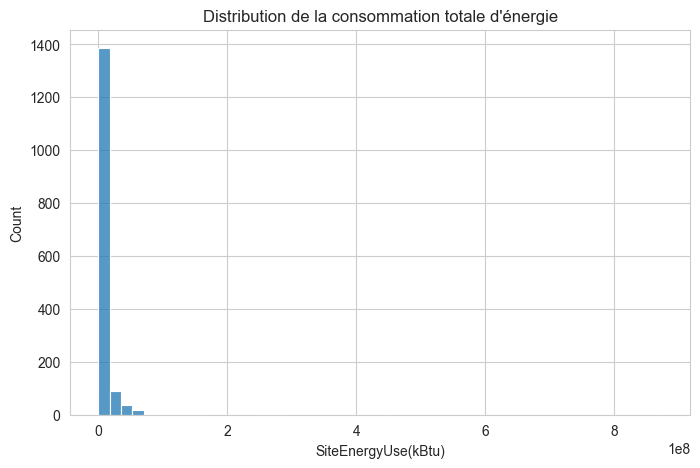

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="SiteEnergyUse(kBtu)", bins=50)
plt.title("Distribution de la consommation totale d'énergie")
plt.xlabel("SiteEnergyUse(kBtu)")
plt.show()

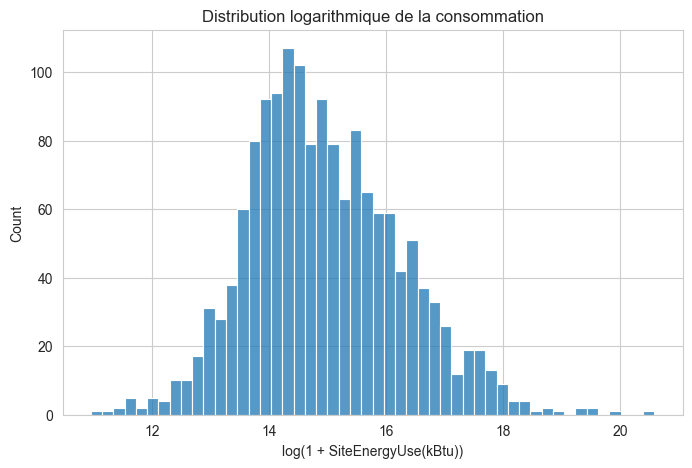

In [ ]:
plt.figure(figsize=(8, 5))
plt.figure(figsize=(8, 5))
sns.histplot(x=np.log1p(df["SiteEnergyUse(kBtu)"]), bins=50)
plt.title("Distribution logarithmique de la consommation")
plt.xlabel("log(1 + SiteEnergyUse(kBtu))")
plt.show()
plt.title("Distribution logarithmique de la consommation")
plt.xlabel("log(1 + SiteEnergyUse(kBtu))")
plt.show()

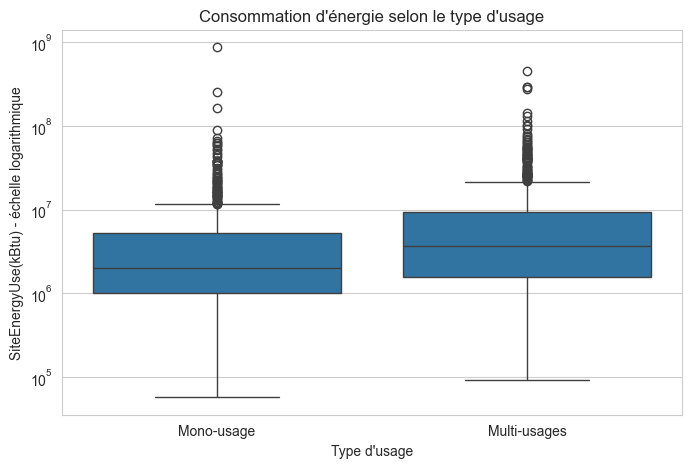

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="UsageType", y="SiteEnergyUse(kBtu)")
plt.yscale("log")
plt.title("Consommation d'énergie selon le type d'usage")
plt.xlabel("Type d'usage")
plt.ylabel("SiteEnergyUse(kBtu) - échelle logarithmique")
plt.show()

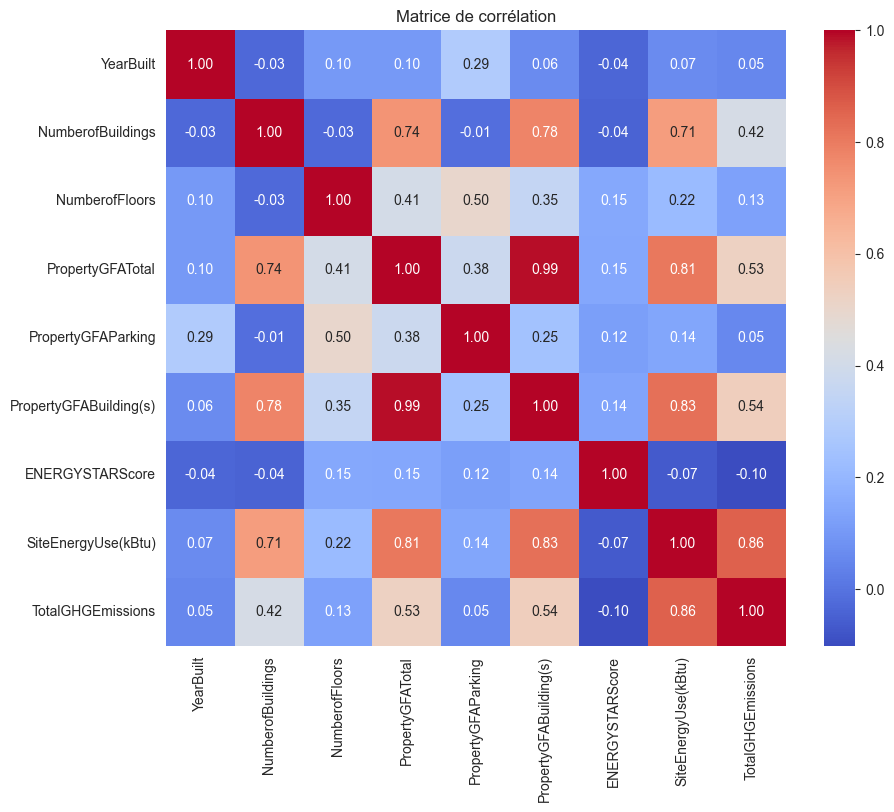

In [24]:
corr_matrix = df[variables_numeriques].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

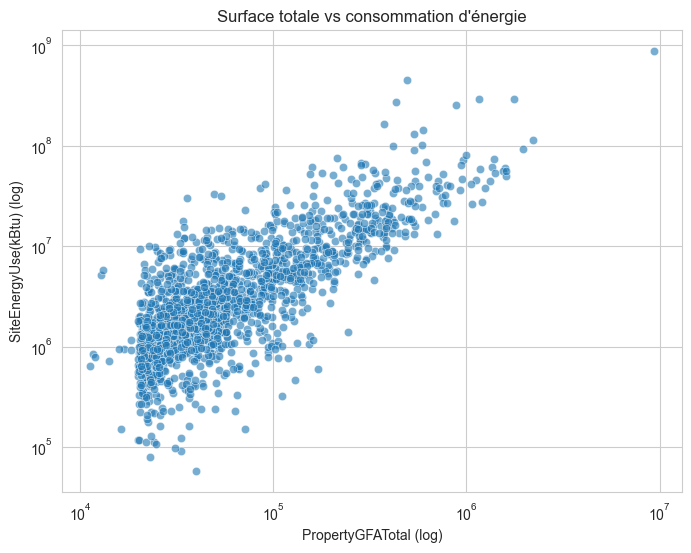

In [25]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="PropertyGFATotal", y="SiteEnergyUse(kBtu)", alpha=0.6)
plt.xscale("log")
plt.yscale("log")
plt.title("Surface totale vs consommation d'énergie")
plt.xlabel("PropertyGFATotal (log)")
plt.ylabel("SiteEnergyUse(kBtu) (log)")
plt.show()

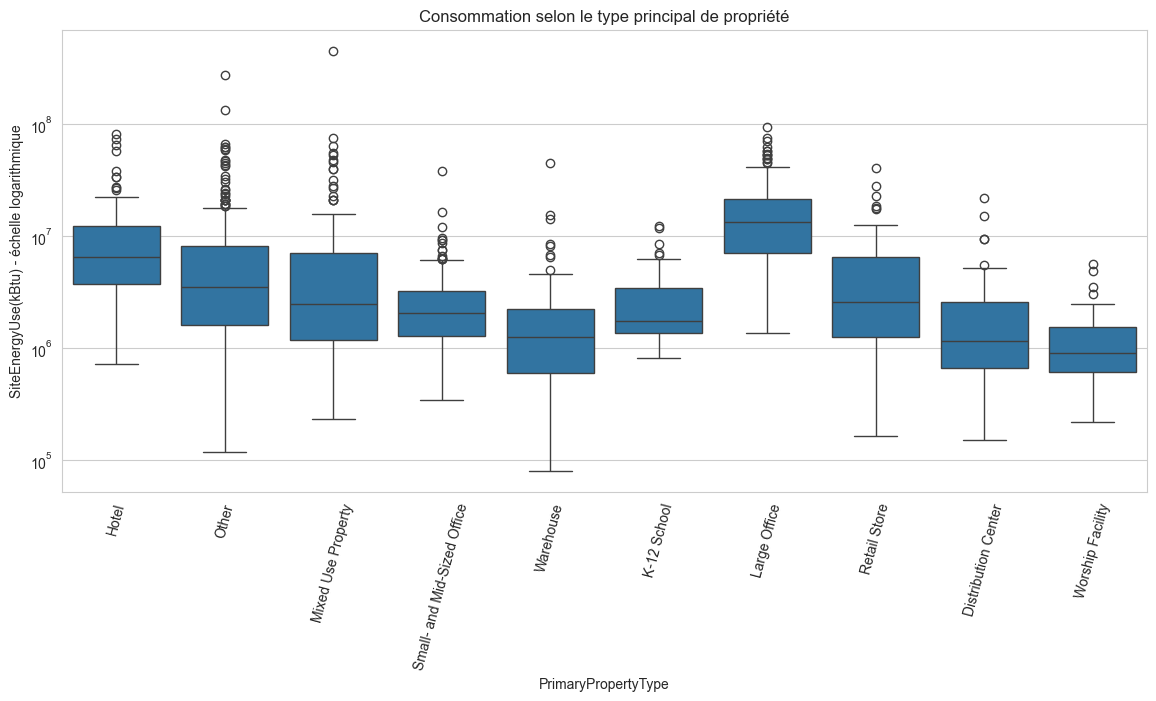

In [26]:
top_property_types = df["PrimaryPropertyType"].value_counts().head(10).index

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df[df["PrimaryPropertyType"].isin(top_property_types)],
    x="PrimaryPropertyType",
    y="SiteEnergyUse(kBtu)"
)
plt.xticks(rotation=75)
plt.yscale("log")
plt.title("Consommation selon le type principal de propriété")
plt.xlabel("PrimaryPropertyType")
plt.ylabel("SiteEnergyUse(kBtu) - échelle logarithmique")
plt.show()

In [27]:
aberrants = df[
    (df["PropertyGFATotal"] <= 0) |
    (df["NumberofFloors"] <= 0) |
    (df["SiteEnergyUse(kBtu)"] <= 0)
]

print("Nombre de lignes potentiellement aberrantes :", aberrants.shape[0])
aberrants.head()

Nombre de lignes potentiellement aberrantes : 16


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity,UsageType
166,267,2016,NonResidential,Hotel,7,DOWNTOWN,47.61275,-122.33330,1999,1.0,0,934292,0,934292,"Hotel, Other, Parking, Restaurant, Retail Store",Hotel,495536.0,Parking,438756.0,Restaurant,49700.0,NaN,117.900002,120.500000,272.899994,278.200012,65047284.0,66502836.0,0.0,11536962.00,39364114.0,256831.62500,25683162.0,False,Compliant,1638.46,1.75,Multi-usages
487,656,2016,NonResidential,Medical Office,3,EAST,47.60979,-122.32298,2004,1.0,0,225982,0,225982,Medical Office,Medical Office,200184.0,NaN,NaN,NaN,NaN,53.0,102.699997,103.699997,246.899994,245.300003,20560622.0,20764814.0,7815663.0,3735333.25,12744957.0,0.00000,0.0,False,Compliant,692.12,3.06,Mono-usage
488,657,2016,NonResidential,Mixed Use Property,7,DOWNTOWN,47.61783,-122.33729,2006,0.0,0,516407,0,516407,"Financial Office, Hotel, Multifamily Housing, ...",Parking,385196.0,Multifamily Housing,340236.0,Hotel,67627.0,31.0,76.300003,78.900002,199.199997,202.000000,39403320.0,40754364.0,0.0,8626261.00,29432803.0,99705.11719,9970512.0,False,Compliant,734.72,1.42,Multi-usages
564,758,2016,NonResidential,Other,7,DOWNTOWN,47.61289,-122.33531,1999,1.0,0,947987,0,947987,"Office, Other - Entertainment/Public Assembly,...",Other - Mall,561684.0,Other - Entertainment/Public Assembly,100000.0,Restaurant,80000.0,NaN,62.299999,62.099998,195.600006,194.899994,46510960.0,46343304.0,0.0,13631581.00,46510954.0,0.00000,0.0,False,Compliant,324.25,0.34,Multi-usages
1754,23311,2016,NonResidential,Medical Office,3,EAST,47.60862,-122.32372,1945,1.0,0,274568,0,274568,"Medical Office, Parking",Medical Office,228133.0,Parking,135954.0,NaN,NaN,52.0,111.000000,111.199997,235.500000,233.100006,25311526.0,25358122.0,13296249.0,3521475.75,12015275.0,0.00000,0.0,False,Compliant,1110.07,4.04,Multi-usages


In [28]:
df = df[
    (df["PropertyGFATotal"] > 0) &
    (df["NumberofFloors"] > 0) &
    (df["SiteEnergyUse(kBtu)"] > 0)
].copy()

print("Dimensions finales après nettoyage :", df.shape)

Dimensions finales après nettoyage : (1531, 38)


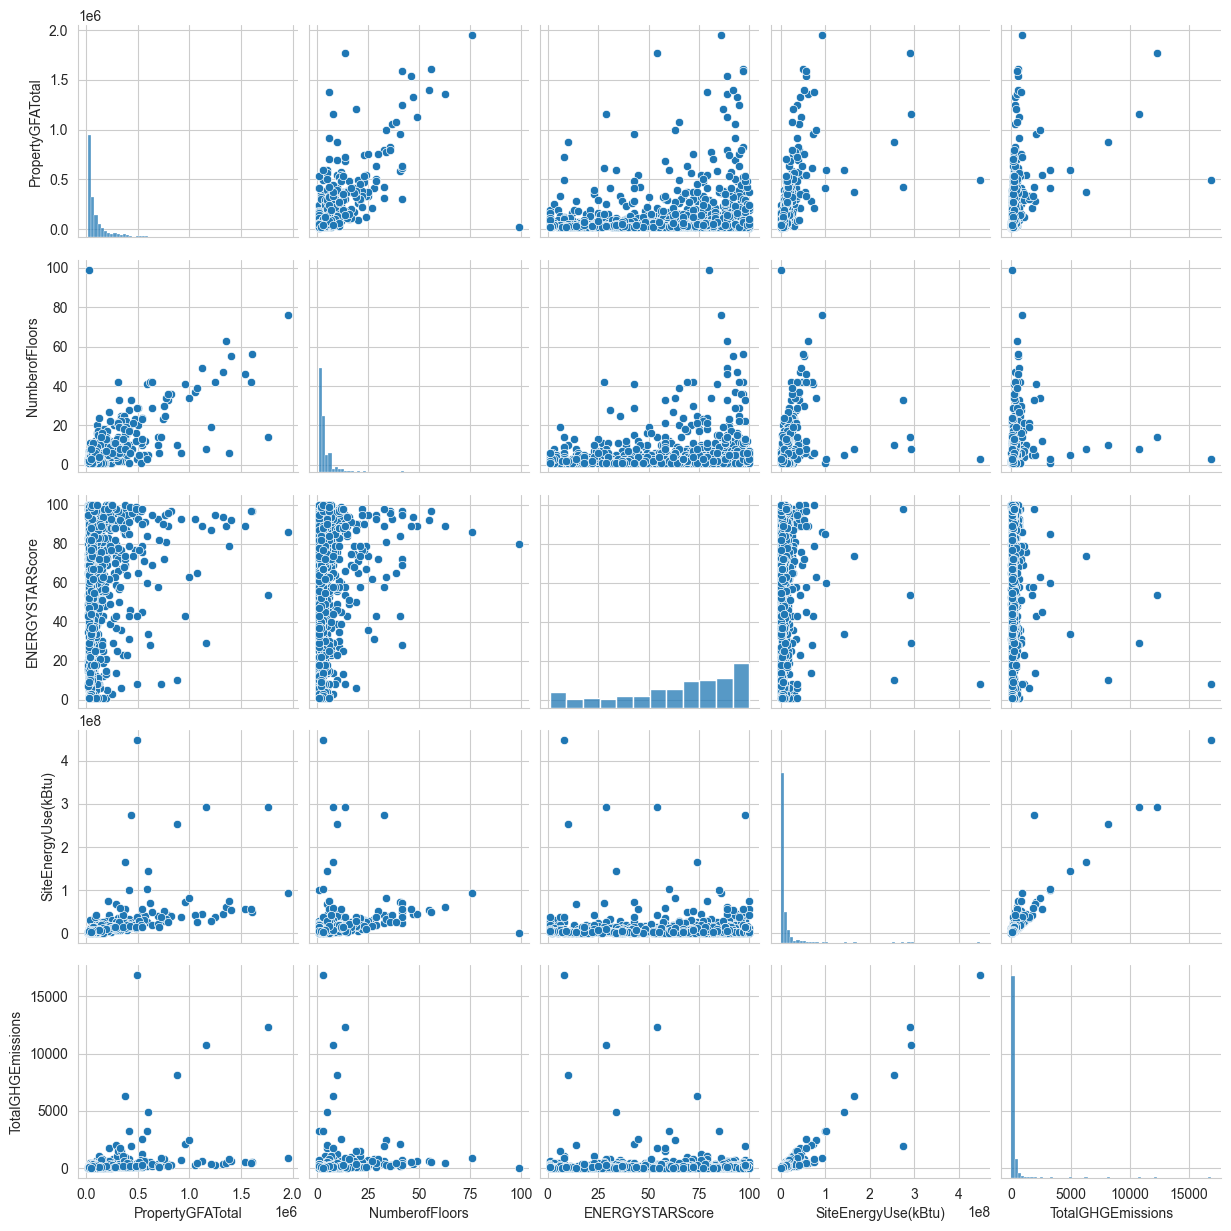

In [29]:
pairplot_cols = [
    "PropertyGFATotal",
    "NumberofFloors",
    "ENERGYSTARScore",
    "SiteEnergyUse(kBtu)",
    "TotalGHGEmissions"
]

sns.pairplot(df[pairplot_cols].dropna())
plt.show()

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

# Modélisation 

### Import des modules 

In [30]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

In [31]:
# CODE FEATURE ENGINEERING

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn 
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

In [32]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [33]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [34]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE